# Visualization of CNNTCNMLPRegressor Predictions

This notebook loads a pre-trained regression model and visualizes its predictions and attention weights on a random test sample.

In [4]:
import os
import sys
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from torch.utils.data import DataLoader, Subset

# Add project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from models.model_regression import CNNTCNMLPRegressor
from models.model_regression import CNNBiLSTMMLPRegressor
from utils.train_utils.dataset import LPBSDataset

Using PyTorch features: ['X', 'Y', 'ComputedSpeed_frames', 'Lifetime']


In [5]:
from scipy.interpolate import make_interp_spline
from scipy.special import gamma
from scipy.signal import savgol_filter
import torch
import zipfile
import os

def _resolve_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return os.path.abspath(p)
    return None

def get_dataset(data_dir, scaler_type, scaler_config_path, device):
    resolved_data_dir = _resolve_existing_path([
        data_dir,
        os.path.join(os.getcwd(), data_dir),
        os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), data_dir),
    ])
    if resolved_data_dir is None:
        raise FileNotFoundError(
            f"Dataset directory not found. Tried: {data_dir}, cwd-relative, and project-root-relative paths."
        )

    resolved_scaler_config = _resolve_existing_path([
        scaler_config_path,
        os.path.join(os.getcwd(), scaler_config_path),
        os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), scaler_config_path),
    ])
    if scaler_type != "none" and resolved_scaler_config is None:
        raise FileNotFoundError(
            f"Scaler config not found. Tried: {scaler_config_path}, cwd-relative, and project-root-relative paths."
        )

    dataset = LPBSDataset(
        resolved_data_dir,
        scaler_type=scaler_type,
        mode="test",
        scaler_config_path=resolved_scaler_config if resolved_scaler_config is not None else scaler_config_path,
        device=device
    )
    print(f"Dataset path: {resolved_data_dir}")
    print(f"Dataset size: {len(dataset)}")
    return dataset

def get_model(
    model_path,
    segment_len,
    device,
    model_type="tcn",
    embed_dim=64,
    dropout=0.4,
    feature_extractor_layers=3,
    bilstm_layers=1,
    kernel_size=3,
    dropout_1d=True,
    use_time_encoding=True,
    ):
    if model_type == "tcn":
        model = CNNTCNMLPRegressor(
            segment_len=segment_len,
            embed_dim=embed_dim,
            dropout=dropout,
            feature_extractor_layers=feature_extractor_layers,
            kernel_size=kernel_size,
            use_time_encoding=use_time_encoding,
            dropout_1d=dropout_1d,
        ).to(device)
    else:
        model = CNNBiLSTMMLPRegressor(
            segment_len=segment_len,
            embed_dim=embed_dim,
            dropout=dropout,
            feature_extractor_layers=feature_extractor_layers,
            bilstm_layers=bilstm_layers,
            use_time_encoding=use_time_encoding,
        ).to(device)

    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print("Model loaded successfully.")
    else:
        print(f"Warning: Model file not found at {model_path}. Using uninitialized model for demonstration.")
    model.eval()
    return model

def plot_data_histogram(dataset):
    x_values = []
    for i in range(len(dataset)):
        x, _, _ = dataset[i]
        x_values.append(x.cpu().numpy())
    x_values = np.concatenate(x_values, axis=0)
    plt.hist(x_values.flatten(), bins=200, edgecolor='black', log=True)
    plt.title("Histogram of dataset values")
    plt.show()

def run_inference(dataset, model, device, random_idx=None, max_segment_number=150):
    if random_idx is None:
        random_idx = random.randint(0, len(dataset) - 1)
    data_tensor, label, total_segments = dataset[random_idx]
    data_tensor = data_tensor.cpu()
    T_actual = int(total_segments.item())
    rul_cap = max_segment_number // 3
    
    print(f"Selected sample {random_idx} with {T_actual} valid segments.")
    
    predictions = []
    alpha_values = []
    beta_values = []
    variances = []
    true_remaining = []
    true_objective = []
    s_weights_all = []
    v_weights_all = []
    
    with torch.no_grad():
        for t in range(1, T_actual + 1):
            x_t = data_tensor[:t].unsqueeze(0).to(device)
            mask = torch.ones(1, t).to(device)
            preds, s_weights, v_weights, _ = model(x_t, mask=mask)
            
            if isinstance(preds, tuple):
                alpha, beta = preds
                alpha_value = float(alpha.item())
                beta_value = max(float(beta.item()), 1e-6)
                expected_rul_norm = alpha_value * float(gamma(1.0 + 1.0 / beta_value))
                point_pred = expected_rul_norm * rul_cap
            else:
                point_pred = float(preds.item()) * rul_cap
                alpha_value = point_pred / rul_cap
                beta_value = np.nan
            
            predictions.append(point_pred)
            alpha_values.append(alpha_value)
            beta_values.append(beta_value)
            variances.append(1.0 / beta_value if np.isfinite(beta_value) else 1.0)
            true_remaining.append(float(T_actual - t))
            true_objective.append(min(float(T_actual - t), rul_cap))
            
            s_weights_all.append(s_weights.squeeze().cpu().numpy())
            v_weights_all.append(v_weights.squeeze().cpu().numpy())

    return T_actual, true_objective, true_remaining, predictions, variances, alpha_values, beta_values, s_weights_all, v_weights_all, data_tensor

def plot_predictions(T_actual, true_objective, true_remaining, predictions, s_weights_cpu):
    steps = np.arange(1, T_actual + 1)

    # Create a smoothed version of the predictions using Savitzky-Golay filter
    window = min(25, len(predictions) if len(predictions) % 2 == 1 else len(predictions) - 1)
    window = max(window, 5)  # keep it valid and strong enough
    predictions_filtered = savgol_filter(predictions, window_length=window, polyorder=2, mode="interp")
    steps_smooth = np.linspace(1, T_actual, 400)
    k = 1 if len(steps) >= 4 else 1
    spline = make_interp_spline(steps, predictions_filtered, k=k)
    predictions_smooth = spline(steps_smooth)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(steps, true_remaining, label="True Remaining Lifespan", linestyle="--", marker="o", markersize=4)
    plt.plot(steps, true_objective, label="True Objective (capped)", color='lightblue', linestyle=":", marker="s", markersize=4)
    plt.plot(steps, predictions, label="Predicted Remaining (Weibull mean)", color='red', marker="x", markersize=4)
    plt.plot(steps_smooth, predictions_smooth, label="Smoothed Predicted Remaining", color='green')
    plt.xlabel("Segments observed (time)")
    plt.ylabel("Remaining segments")
    plt.title("Remaining Lifespan Prediction Over Time")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    # Using the final step's attention weights for plotting
    plt.bar(np.arange(1, len(s_weights_cpu[-1]) + 1), s_weights_cpu[-1], color='skyblue', edgecolor='black')
    plt.xlabel("Segment index")
    plt.ylabel("Attention Weight")
    plt.title("Segment Attention Weights (at final step)")
    plt.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()

def plot_variances(v_weights_cpu):
    plt.figure(figsize=(10, 6))
    # Using the final step's attention weights for plotting
    weights_to_plot = v_weights_cpu[-1]
    if len(weights_to_plot.shape) == 1:
        weights_to_plot = weights_to_plot[:, np.newaxis]
    plt.imshow(weights_to_plot.T, aspect='auto', cmap='viridis', origin='lower')
    var_dict = {0: "X", 1: "Y", 2: "Speed"}
    plt.yticks(np.arange(weights_to_plot.shape[1]), [var_dict.get(i, f"Var {i}") for i in range(weights_to_plot.shape[1])])
    plt.colorbar(label='Attention Weight')
    plt.xlabel("Segment index")
    plt.ylabel("Variate")
    plt.title("Variate Attention Weights Over Time (at final step)")
    plt.tight_layout()
    plt.show()

def analyze_gradients(model, data_tensor, T_actual, device):
    import torch.nn as nn
    model.zero_grad()
    model.train()
    
    x_full = data_tensor[:T_actual].unsqueeze(0).to(device)
    mask_full = torch.ones(1, T_actual).to(device)
    
    preds, _, _, _ = model(x_full, mask=mask_full)
    if isinstance(preds, tuple):
        output = preds[0]
    else:
        output = preds
    target = torch.tensor([0.0], device=device)
    
    criterion = nn.SmoothL1Loss()
    loss = criterion(output, target)
    loss.backward()
    
    max_grads = {}
    for name, param in model.feature_extractors.named_parameters():
        if param.grad is not None:
            max_grads[name] = param.grad.abs().max().item()
            
    print("Max absolute gradients in CNN Feature Extractor parameters:")
    for name, max_g in max_grads.items():
        print(f"  {name}: {max_g:.6f}")
        
    plt.figure(figsize=(10, 4))
    plt.bar(list(max_grads.keys()), list(max_grads.values()), color='lightcoral', edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Max Absolute Gradient')
    plt.title('Max Gradients in CNN Feature Extractor (Huber Loss)')
    plt.tight_layout()
    plt.show()

## 1. Configurations and Loading
Specify the paths to the dataset, the pre-trained model weights, and the required scaler configuration.

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Resolve project root robustly (works from project root or notebook/ subfolder)
cwd = os.getcwd()
project_root = cwd if os.path.isdir(os.path.join(cwd, "preprocessed_data")) else os.path.abspath(os.path.join(cwd, ".."))

# Settings (matched to tcn_regr_64e_3_k3 config)
data_dir = os.path.join(project_root, "preprocessed_data")
scaler_config_path = os.path.join(project_root, "preprocessed_data", "scaler_config.json")
model_path = os.path.join(project_root, "ckpts", "tcn_regr_64e_bs16_3_k3_17-52.pth")
scaler_type = "standard"

model_type = "tcn"
kernel_size = 3
dropout = 0.4
dropout_1d = True
embed_dim = 64
feature_extractor_layers = 3
batch_size = 16
loss = "weibull"
lr = 5e-4
patience = 25
epochs = 500
segment_len = 900
use_time_encoding = True

print(f"Resolved data_dir: {data_dir}")
print(f"Resolved scaler_config_path: {scaler_config_path}")
print(f"Resolved model_path: {model_path}")

Using device: cuda
Resolved data_dir: /content/drive/MyDrive/project-2-astiflop/preprocessed_data
Resolved scaler_config_path: /content/drive/MyDrive/project-2-astiflop/preprocessed_data/scaler_config.json
Resolved model_path: /content/drive/MyDrive/project-2-astiflop/ckpts/tcn_regr_64e_bs16_3_k3_17-52.pth


In [15]:
dataset = get_dataset(data_dir, scaler_type, scaler_config_path, device)

Loading Data: 100%|██████████| 92/92 [00:22<00:00,  4.10it/s]

Applied standard normalization.
Dataset path: /content/drive/MyDrive/project-2-astiflop/preprocessed_data
Dataset size: 92


In [16]:
bilstm_layers = 1
model = get_model(
    model_path=model_path,
    segment_len=segment_len,
    device=device,
    model_type=model_type,
    embed_dim=embed_dim,
    dropout=dropout,
    feature_extractor_layers=feature_extractor_layers,
    bilstm_layers=bilstm_layers,
    kernel_size=kernel_size,
    dropout_1d=dropout_1d,
    use_time_encoding=use_time_encoding,
    )

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


## Visualization

Selected sample 21 with 110 valid segments.


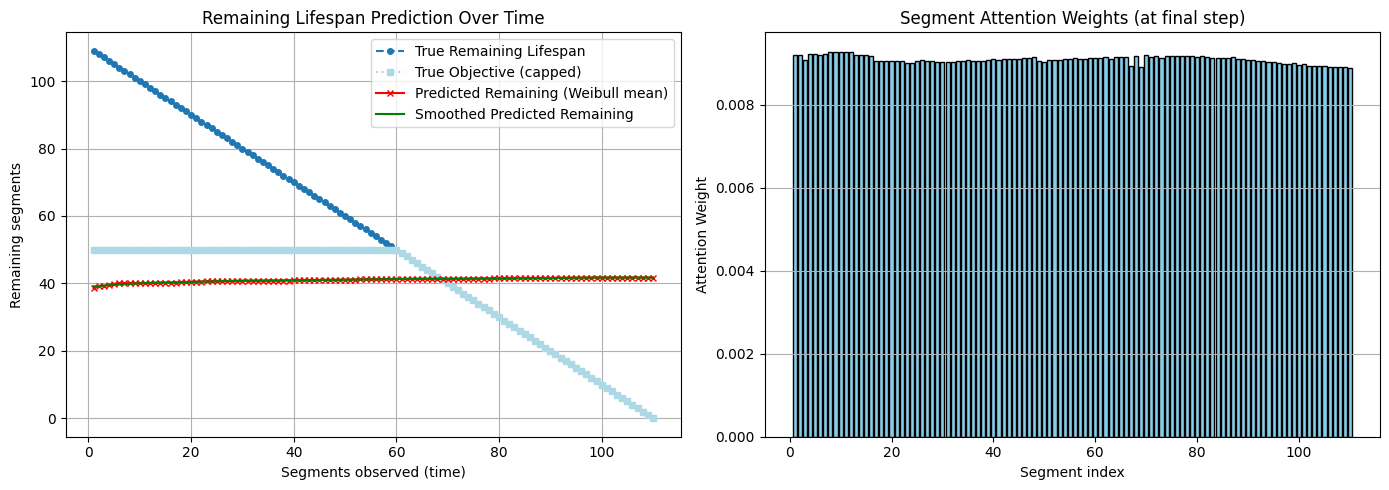

In [17]:
T_actual, true_objective, true_remaining, predictions, variances, alpha_values, beta_values, s_weights_all, v_weights_all, data_tensor = run_inference(dataset, model, device)
plot_predictions(T_actual, true_objective, true_remaining, predictions, s_weights_all)

In [18]:
import zipfile
import os

# Dump the inference variables
dump_dict = {
    'T_actual': T_actual,
    'true_objective': true_objective,
    'true_remaining': true_remaining,
    'predictions': predictions,
    'variances': variances,
    's_weights_cpu': s_weights_all,
    'v_weights_cpu': v_weights_all,
    'data_tensor': data_tensor
}

dump_file = 'inference_dump_time.pt'
torch.save(dump_dict, dump_file)

# Zip the dump
with zipfile.ZipFile('inference_dump.zip', 'w') as zipf:
    zipf.write(dump_file)

print("Inference data dumped to inference_dump.zip")

Inference data dumped to inference_dump.zip


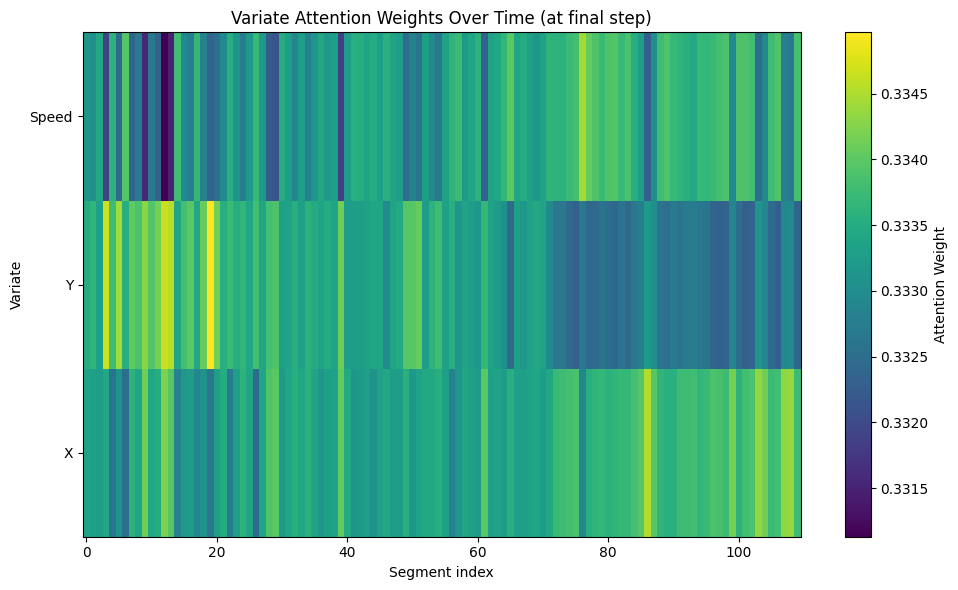

In [19]:
plot_variances(v_weights_all)

Max absolute gradients in CNN Feature Extractor parameters:
  0.conv1.weight: 0.000239
  0.conv1.bias: 0.000240
  0.conv2.weight: 0.001141
  0.conv2.bias: 0.000961
  0.conv3.weight: 0.001010
  0.conv3.bias: 0.002322
  0.fc.weight: 0.001651
  0.fc.bias: 0.005786
  1.conv1.weight: 0.000256
  1.conv1.bias: 0.000300
  1.conv2.weight: 0.000604
  1.conv2.bias: 0.000680
  1.conv3.weight: 0.000737
  1.conv3.bias: 0.001670
  1.fc.weight: 0.002017
  1.fc.bias: 0.006876
  2.conv1.weight: 0.000299
  2.conv1.bias: 0.000308
  2.conv2.weight: 0.000752
  2.conv2.bias: 0.000855
  2.conv3.weight: 0.002390
  2.conv3.bias: 0.003631
  2.fc.weight: 0.001956
  2.fc.bias: 0.005851


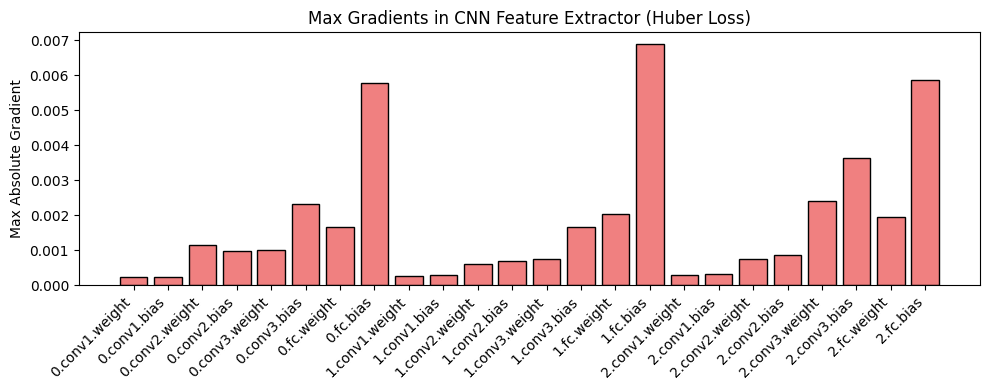

In [20]:
analyze_gradients(model, data_tensor, T_actual, device)

In [21]:
import torch
import zipfile
import os

dump_file = 'inference_dump_time.pt'

# Unzip the dump
with zipfile.ZipFile('inference_dump.zip', 'r') as zipf:
    zipf.extract(dump_file)

# Load variables
dump_dict = torch.load(dump_file, weights_only=False)
T_actual_loaded = dump_dict['T_actual']
true_objective_loaded = dump_dict['true_objective']
true_remaining_loaded = dump_dict['true_remaining']
predictions_loaded = dump_dict['predictions']
s_weights_loaded = dump_dict['s_weights_cpu']
v_weights_loaded = dump_dict['v_weights_cpu']
data_tensor_loaded = dump_dict['data_tensor']

print("Variables loaded from inference_dump.zip")

Variables loaded from inference_dump.zip
